<a href="https://colab.research.google.com/github/arnabg2005/my-python-project/blob/main/Cyberbulling_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:

# 1. import libraries
import pandas as pd
import re
import nltk
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# download once
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [56]:
# 2. Load Dataset
df = pd.read_csv('/content/final_dataset_hinglish.csv')

# convert -1 → 1
df['label'] = df['label'].replace(-1, 1)

Class Distribution:

label
1    11661
0     6487
Name: count, dtype: int64


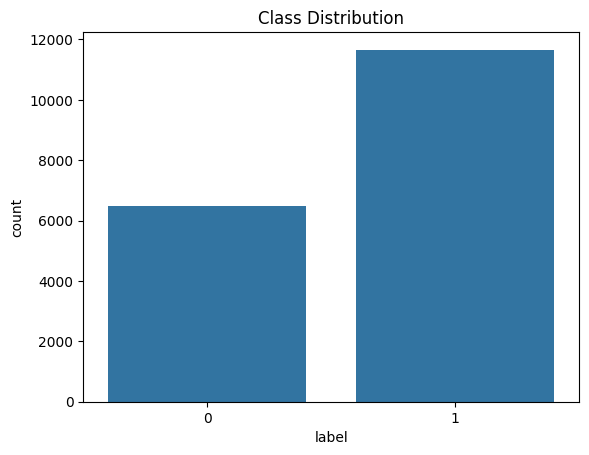

In [57]:
# 3. check the imbalance in the data
print("Class Distribution:\n")
print(df['label'].value_counts())

sns.countplot(x=df['label'])
plt.title("Class Distribution")
plt.show()

In [58]:
# 4. Text cleaning function
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()

    words = [w for w in text.split() if len(w) > 3]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df['clean_text'] = df['headline'].apply(clean_text)

In [59]:
# 5. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['label'],
    test_size=0.3,
    random_state=42,
    stratify=df['label']
)


In [60]:
# 6. LINEARSVC (WITH CONFIDENCE)
svc_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('classifier', CalibratedClassifierCV(LinearSVC(), method='sigmoid'))
])

svc_pipeline.fit(X_train, y_train)
svc_pred = svc_pipeline.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [61]:
# 7. RANDOM FOREST
rf_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('classifier', RandomForestClassifier(n_estimators=100))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

In [62]:
# 8. EVALUATION FUNCTION
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

svc_metrics = get_metrics(y_test, svc_pred)
rf_metrics = get_metrics(y_test, rf_pred)

In [63]:
# 9. COMPARISON TABLE
comparison = pd.DataFrame([
    {"Model": "LinearSVC", **svc_metrics},
    {"Model": "RandomForest", **rf_metrics}
])

print("\n===== MODEL COMPARISON =====\n")
print(comparison)


===== MODEL COMPARISON =====

          Model  Accuracy  Precision    Recall  F1 Score
0     LinearSVC  0.889991   0.910998  0.918548  0.914757
1  RandomForest  0.895133   0.939112  0.894827  0.916435


In [64]:
# 10. BEST MODEL
best_model = comparison.sort_values(by="F1 Score", ascending=False).iloc[0]

print("\nBest Model Based on F1 Score:")
print(best_model)


Best Model Based on F1 Score:
Model        RandomForest
Accuracy         0.895133
Precision        0.939112
Recall           0.894827
F1 Score         0.916435
Name: 1, dtype: object


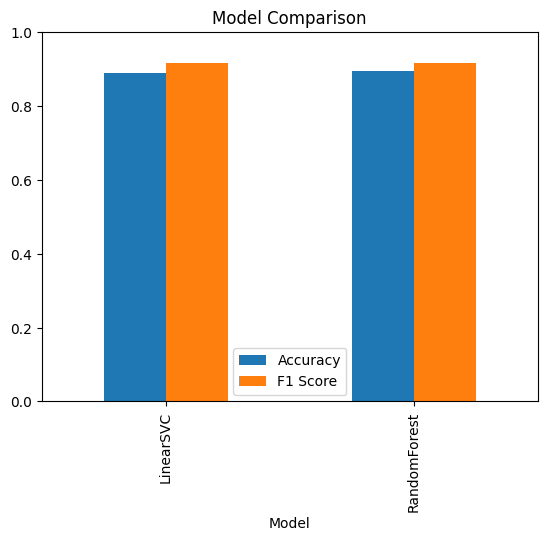

In [65]:
# 11. VISUALIZATION (BAR GRAPH)
comparison.set_index("Model")[["Accuracy", "F1 Score"]].plot(kind="bar")
plt.title("Model Comparison")
plt.ylim(0,1)
plt.show()

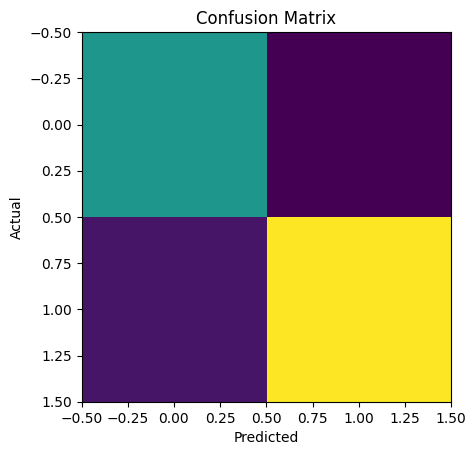

In [66]:
# 12. CONFUSION MATRIX
if best_model['Model'] == "LinearSVC":
    cm = confusion_matrix(y_test, svc_pred)
else:
    cm = confusion_matrix(y_test, rf_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [67]:
# 13. HYBRID MODEL (CONFIDENCE BASED)
def hybrid_predict(text):

    text = clean_text(text)

    svc_prob = svc_pipeline.predict_proba([text])[0]
    rf_prob = rf_pipeline.predict_proba([text])[0]

    svc_conf = max(svc_prob)
    rf_conf = max(rf_prob)

    if svc_conf > rf_conf:
        model_used = "LinearSVC"
        pred = svc_prob.argmax()
        conf = svc_conf
    else:
        model_used = "RandomForest"
        pred = rf_prob.argmax()
        conf = rf_conf

    label = "Bullying" if pred == 1 else "Non-Bullying"

    return model_used, label, round(conf * 100, 2)


In [72]:
# 14. TEST HYBRID SYSTEM
sample = "good boy"

model, pred, conf = hybrid_predict(sample)

print("\nInput:", sample)
print("Model Used:", model)
print("Prediction:", pred)
print("Confidence:", conf, "%")


Input: good boy
Model Used: RandomForest
Prediction: Non-Bullying
Confidence: 69.4 %


In [69]:
# 15. SAVE MODELS
pickle.dump(svc_pipeline, open("svc_model.pkl", "wb"))
pickle.dump(rf_pipeline, open("rf_model.pkl", "wb"))

In [70]:
# ERROR ANALYSIS
print("\n===== Error Analysis =====\n")

errors = []

for text, true, pred in zip(X_test, y_test, y_pred):
    if true != pred:
        errors.append((text, true, pred))

for e in errors[:10]:
    print("Text:", e[0])
    print("Actual:", e[1], "Predicted:", e[2])
    print("------")


===== Error Analysis =====

Text: scriptural evidence volume book number sahih bukhari most venerated authentic islamic source narrated aisha that prophet married when year consummated marriage when nine year then remained with nine year till death july
Actual: 0 Predicted: 1
------
Text: sure there must some confusion related arrest article say boot however wikipedia entry interpreted this also toy shoe sure boot boot
Actual: 0 Predicted: 1
------
Text: comp valo knowledge rahega umang lavde
Actual: 1 Predicted: 0
------
Text: jiska khudka team jagah usko thodi denge captaincy
Actual: 0 Predicted: 1
------
Text: fuck think that vandalized nigger oklahoma city bombing prohibition page haven even been those page thank douschebag getting editing privilages revoked prick
Actual: 1 Predicted: 0
------
Text: article sebastien larroud been speedily deleted from wikipedia this done because article seemed about person group people band club company content indicate subject notable that articl

In [71]:
'''# REAL-TIME PREDICTION
loaded_model = pickle.load(open('pipeline_model.pkl', 'rb'))

def predict_text(text):
    cleaned = clean_text(text)

    if cleaned.strip() == "":
        return "Invalid Input"

    pred = loaded_model.predict([cleaned])[0]

    return "Bullying" if pred == 1 else "Non-Bullying"

# test
sample = "you are a stupid idiot"
print("\nInput:", sample)
print("Prediction:", predict_text(sample))'''

'# REAL-TIME PREDICTION\nloaded_model = pickle.load(open(\'pipeline_model.pkl\', \'rb\'))\n\ndef predict_text(text):\n    cleaned = clean_text(text)\n    \n    if cleaned.strip() == "":\n        return "Invalid Input"\n    \n    pred = loaded_model.predict([cleaned])[0]\n    \n    return "Bullying" if pred == 1 else "Non-Bullying"\n\n# test\nsample = "you are a stupid idiot"\nprint("\nInput:", sample)\nprint("Prediction:", predict_text(sample))'